In [1]:
from sqlalchemy import create_engine
from snowflake.sqlalchemy import URL
import pandas as pd
import numpy as np
from sklearn.ensemble import IsolationForest
import matplotlib.pyplot as plt
import shap

c:\Users\knguy139\Documents\Projects\.venv\Lib\site-packages\snowflake\connector\vendored\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.4.3)/charset_normalizer (3.4.7) doesn't match a supported version!
  warnings.warn(
c:\Users\knguy139\Documents\Projects\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
engine = create_engine(URL(
    account = "UHG-UHGDWAAS",
    user = "KHANG.NGUYEN@UHC.COM",
    authenticator = "externalbrowser",
    role = "AZU_SDRP_VING_PRD_DEVELOPER_ROLE",
    warehouse = "VING_PRD_MNR_HCE_DATAINFRA_WH",
    database = "VING_PRD_TREND_DB",
    schema = "TMP_1M"
))

In [3]:
df_2025 = pd.read_sql("""
    select
        d.collection as hospital_group
        , a.fin_market
        , count(distinct a.case_id) as case_count
        , count(distinct case when a.initialfulladr_cases = 1 then a.case_id end) as initial_adr_cnt
        , count(distinct case when a.persistentfulladr_cases = 1 then a.case_id end) as persistent_adr_cnt
        , count(distinct case when a.p2p_full_ovtn = 1 then a.case_id end) as p2p_ovrtn_cnt
        , count(distinct case when a.appeal_ovrtn_ind = 1 then a.case_id end) as appeal_ovrtn_cnt
        , count(distinct case when a.mcr_ovtrn_ind = 1 then a.case_id end) as mcr_ovrtn_cnt
        , count(distinct case when a.icm_md_reviewed_ind = 1 then a.case_id end) as md_reviewed_cnt
    from tmp_1m.ec_avtar_25_26_3_od as a
    left join tmp_1y.tin_collection as d
        on substr(a.fa_prov_id, 2, 9) = d.tin
    where fin_brand = 'M&R'
        and (
            (ip_type in ('Medical', 'Surgical', 'Transplant')
             and to_varchar(admit_dt_act, 'MM/dd/yyyy') is not null)
            or ip_type in ('LTAC', 'SNF', 'AIR')
        )
        and loc_flag = 1
        and (
            (global_cap = 'NA' and sgr_source_name = 'COSMOS'
             and fin_product_level_3 != 'INSTITUTIONAL' and tfm_include_flag = 1)
            or (sgr_source_name = 'NICE' and nce_tadm_dec_risk_type in ('FFS', 'PHYSICIAN'))
        )
        and hce_admit_month between '202501' and '202512'
        and d.collection is not null
    group by 1,2
    having count(distinct a.case_id) >= 30
""", engine)

print(f"df_2025: {df_2025.shape}")

 pip install snowflake-connector-python[secure-local-storage]


Initiating login request with your identity provider. Press CTRL+C to abort and try again...
Going to open: https://login.microsoftonline.com/db05faca-c82a-4b9d-b9c5-0f64b6755421/saml2?SAMLRequest=lVJdb9owFP0rkfec2AkJAwuooKwa6geswDbxMjm2AxaOndpOQ%2F%2F9nABS99BKe7Bk2efcc%2B49d3RzKmXwyo0VWo1BHCEQcEU1E2o%2FBtvNXTgAgXVEMSK14mPwxi24mYwsKWWFp7U7qGf%2BUnPrAl9IWdx%2BjEFtFNbECosVKbnFjuL19PEBJxHCxFpunJcDFwqzwmsdnKswhE3TRE0v0mYPE4QQREPoUS3kC3gnUX2uURntNNXySjn5nj6QiCFKWwmP8AqrC3Em1HkEn6nkZ5DF3zebVbharjcgmF67u9XK1iU3a25eBeXb54ezAesd1Id96A9rCLF%2FDiSySjeFJEdOdVnVzteM%2FA0WnEGp98JPajEfg%2BooWP5jRsmpIW7HGjT89lDOe7Ra5vf3syey2qllc9zq3y%2FZryJFFAQ%2Fr7kmba4La2u%2BUG2azj%2BhpB%2BifhgPN3GGewOMsijrpTsQzH2aQhHXMa%2BWOx9RKajRVhdOKykU71yyHGUFoSSkg4SEaT5kYT6kWYiKfpr3v2ZZmsSwzSwB573BnREz%2Bb9pjOB77mUBn3wmi%2FlKS0HfgjttSuI%2BjiyO4u5FsLDooJiXRMgpY4Zb66OTUje3hhPn99yZmgM4Oav%2Bu%2BmTvw%3D%3D&RelayState=ver%3A3-hint%3A260092117886646-ETMsDgAAAZ7giD1eABRBRVMvQ0JDL1BLQ1M1UGFkZGluZwEAABAAENxL%2FXIBzwVm0VlhnJRr7t4AAACQHB

In [4]:
df_2026 = pd.read_sql("""
    select
        d.collection as hospital_group
        , a.fin_market
        , count(distinct a.case_id) as case_count
        , count(distinct case when a.initialfulladr_cases = 1 then a.case_id end) as initial_adr_cnt
        , count(distinct case when a.persistentfulladr_cases = 1 then a.case_id end) as persistent_adr_cnt
        , count(distinct case when a.p2p_full_ovtn = 1 then a.case_id end) as p2p_ovrtn_cnt
        , count(distinct case when a.appeal_ovrtn_ind = 1 then a.case_id end) as appeal_ovrtn_cnt
        , count(distinct case when a.mcr_ovtrn_ind = 1 then a.case_id end) as mcr_ovrtn_cnt
        , count(distinct case when a.icm_md_reviewed_ind = 1 then a.case_id end) as md_reviewed_cnt
        , count(distinct case when a.member_appeal_ind = 1 then a.case_id end) as member_appeal_cnt
        , count(distinct case when a.member_appeal_ovtn_ind = 1 then a.case_id end) as member_appeal_ovtn_cnt
    from tmp_1m.ec_avtar_25_26_3_od as a
    left join tmp_1y.tin_collection as d
        on substr(a.fa_prov_id, 2, 9) = d.tin
    where fin_brand = 'M&R'
        and (
            (ip_type in ('Medical', 'Surgical', 'Transplant')
             and to_varchar(admit_dt_act, 'MM/dd/yyyy') is not null)
            or ip_type in ('LTAC', 'SNF', 'AIR')
        )
        and loc_flag = 1
        and (
            (global_cap = 'NA' and sgr_source_name = 'COSMOS'
             and fin_product_level_3 != 'INSTITUTIONAL' and tfm_include_flag = 1)
            or (sgr_source_name = 'NICE' and nce_tadm_dec_risk_type in ('FFS', 'PHYSICIAN'))
        )
        and hce_admit_month between '202601' and '202604'
        and d.collection is not null
    group by 1,2
    having count(distinct a.case_id) >= 30
""", engine)

print(f"df_2026: {df_2026.shape}")

df_2026: (1026, 11)


In [5]:
def mom_optimal_k(successes, trials):
    """Compute optimal shrinkage k via Method-of-Moments Beta-Binomial.

    Models hospital rates as p_i ~ Beta(alpha, beta). Returns k = alpha + beta,
    the prior pseudo-sample-size that controls shrinkage intensity.
    Uses HARMONIC mean of denominators to correctly estimate sampling variance
    under heterogeneous hospital volumes.
    Falls back to k=50 if signal variance <= 0 (all variation is noise).
    """
    mask = (trials > 0) & (successes >= 0)
    s, n = successes[mask].values, trials[mask].values
    p = s / n
    p_bar = p.mean()
    v_obs = p.var(ddof=1)
    n_bar = len(n) / np.sum(1.0 / n)  # v4 fix: harmonic mean for skewed volumes
    v_sampling = p_bar * (1 - p_bar) / n_bar
    v_signal = v_obs - v_sampling
    if v_signal <= 0:
        return 50.0
    alpha_hat = p_bar * (p_bar * (1 - p_bar) / v_signal - 1)
    beta_hat = (1 - p_bar) * (p_bar * (1 - p_bar) / v_signal - 1)
    if alpha_hat <= 0 or beta_hat <= 0:
        return 50.0
    return alpha_hat + beta_hat


def compute_rates_and_shrinkage(df, year, has_member_appeal=False, k_map=None):
    """Compute raw rates, apply per-feature Bayes shrinkage, filter to IF-eligible.

    v4 fix: Global rates are computed from the >=30 case population BEFORE
    applying the >=10 ADR filter. This removes survivorship bias in shrinkage targets.
    """
    df = df.assign(
        initial_adr_rate = lambda x: x.initial_adr_cnt / x.case_count,
        persistent_adr_rate = lambda x: x.persistent_adr_cnt / x.case_count,
        p2p_overturn_rate = lambda x: x.p2p_ovrtn_cnt / x.initial_adr_cnt.replace(0, np.nan),
        appeal_overturn_rate = lambda x: x.appeal_ovrtn_cnt / x.initial_adr_cnt.replace(0, np.nan),
        mcr_overturn_rate = lambda x: x.mcr_ovrtn_cnt / x.initial_adr_cnt.replace(0, np.nan),
        md_review_rate = lambda x: x.md_reviewed_cnt / x.case_count,
    )
    if has_member_appeal:
        df = df.assign(
            member_appeal_rate = lambda x: x.member_appeal_cnt / x.initial_adr_cnt.replace(0, np.nan),
        )

    rate_cols = [
        "initial_adr_rate", "persistent_adr_rate", "p2p_overturn_rate",
        "appeal_overturn_rate", "mcr_overturn_rate", "md_review_rate",
    ]
    if has_member_appeal:
        rate_cols.append("member_appeal_rate")

    count_cols = [
        "case_count", "initial_adr_cnt", "persistent_adr_cnt",
        "p2p_ovrtn_cnt", "appeal_ovrtn_cnt", "mcr_ovrtn_cnt", "md_reviewed_cnt"
    ]
    if has_member_appeal:
        count_cols += ["member_appeal_cnt", "member_appeal_ovtn_cnt"]

    df[rate_cols + count_cols] = df[rate_cols + count_cols].replace([np.inf, -np.inf], np.nan).fillna(0)

    # v4 fix: compute global rates from FULL >=30 case population (before ADR filter)
    df_broad = df.query("case_count >= 30").copy()
    gr_initial_adr = df_broad["initial_adr_cnt"].sum() / df_broad["case_count"].sum()
    gr_persistent = df_broad["persistent_adr_cnt"].sum() / df_broad["case_count"].sum()
    denom_adr_broad = df_broad.loc[df_broad["initial_adr_cnt"] > 0, "initial_adr_cnt"].sum()
    gr_p2p = df_broad["p2p_ovrtn_cnt"].sum() / denom_adr_broad if denom_adr_broad > 0 else 0
    gr_appeal = df_broad["appeal_ovrtn_cnt"].sum() / denom_adr_broad if denom_adr_broad > 0 else 0
    gr_mcr = df_broad["mcr_ovrtn_cnt"].sum() / denom_adr_broad if denom_adr_broad > 0 else 0
    gr_md = df_broad["md_reviewed_cnt"].sum() / df_broad["case_count"].sum()

    # NOW apply the >=10 ADR filter for IF input
    df_iso = df.query("case_count >= 30 and initial_adr_cnt >= 10").copy()

    if k_map is None:
        k_map = {feat: 50.0 for feat in ["initial_adr", "persistent_adr", "p2p_overturn",
                                           "appeal_overturn", "mcr_overturn", "md_review", "member_appeal"]}

    df_iso["initial_adr_adj_rate"] = (df_iso["initial_adr_cnt"] + k_map["initial_adr"] * gr_initial_adr) / (df_iso["case_count"] + k_map["initial_adr"])
    df_iso["persistent_adr_adj_rate"] = (df_iso["persistent_adr_cnt"] + k_map["persistent_adr"] * gr_persistent) / (df_iso["case_count"] + k_map["persistent_adr"])
    df_iso["p2p_overturn_adj_rate"] = (df_iso["p2p_ovrtn_cnt"] + k_map["p2p_overturn"] * gr_p2p) / (df_iso["initial_adr_cnt"] + k_map["p2p_overturn"])
    df_iso["appeal_overturn_adj_rate"] = (df_iso["appeal_ovrtn_cnt"] + k_map["appeal_overturn"] * gr_appeal) / (df_iso["initial_adr_cnt"] + k_map["appeal_overturn"])
    df_iso["mcr_overturn_adj_rate"] = (df_iso["mcr_ovrtn_cnt"] + k_map["mcr_overturn"] * gr_mcr) / (df_iso["initial_adr_cnt"] + k_map["mcr_overturn"])
    df_iso["md_review_adj_rate"] = (df_iso["md_reviewed_cnt"] + k_map["md_review"] * gr_md) / (df_iso["case_count"] + k_map["md_review"])

    df_iso["log_case_count"] = np.log1p(df_iso["case_count"])
    df_iso["log_initial_adr_cnt"] = np.log1p(df_iso["initial_adr_cnt"])

    if has_member_appeal:
        gr_member_appeal = df_broad["member_appeal_cnt"].sum() / denom_adr_broad if denom_adr_broad > 0 else 0
        df_iso["member_appeal_adj_rate"] = (df_iso["member_appeal_cnt"] + k_map["member_appeal"] * gr_member_appeal) / (df_iso["initial_adr_cnt"] + k_map["member_appeal"])

    df_iso["year"] = year
    return df_iso

In [6]:
df_all = pd.concat([
    df_2025.query("case_count >= 30").assign(
        initial_adr_rate = lambda x: x.initial_adr_cnt / x.case_count
    ).query("initial_adr_cnt >= 10"),
    df_2026.query("case_count >= 30").assign(
        initial_adr_rate = lambda x: x.initial_adr_cnt / x.case_count
    ).query("initial_adr_cnt >= 10")
], ignore_index=True)

rate_configs = {
    "initial_adr":    {"num": "initial_adr_cnt",    "denom": "case_count"},
    "persistent_adr": {"num": "persistent_adr_cnt",  "denom": "case_count"},
    "p2p_overturn":   {"num": "p2p_ovrtn_cnt",      "denom": "initial_adr_cnt"},
    "appeal_overturn": {"num": "appeal_ovrtn_cnt",   "denom": "initial_adr_cnt"},
    "mcr_overturn":   {"num": "mcr_ovrtn_cnt",      "denom": "initial_adr_cnt"},
    "md_review":      {"num": "md_reviewed_cnt",     "denom": "case_count"},
}

k_map = {}
print("Per-Feature Optimal k (Method-of-Moments Beta-Binomial, harmonic mean)")
print("=" * 60)
for feat, cfg in rate_configs.items():
    k_opt = mom_optimal_k(df_all[cfg["num"]], df_all[cfg["denom"]])
    k_map[feat] = k_opt
    print(f"  {feat:<20}: k = {k_opt:.1f}")

if "member_appeal_cnt" in df_2026.columns:
    df_26_elig = df_2026.query("case_count >= 30 and initial_adr_cnt >= 10")
    k_ma = mom_optimal_k(df_26_elig["member_appeal_cnt"], df_26_elig["initial_adr_cnt"])
    k_map["member_appeal"] = k_ma
    print(f"  {'member_appeal':<20}: k = {k_ma:.1f} (2026 only)")

print(f"\nk_map: {k_map}")

Per-Feature Optimal k (Method-of-Moments Beta-Binomial, harmonic mean)
  initial_adr         : k = 20.4
  persistent_adr      : k = 27.8
  p2p_overturn        : k = 8.9
  appeal_overturn     : k = 22.6
  mcr_overturn        : k = 54.6
  md_review           : k = 8.7
  member_appeal       : k = 4.0 (2026 only)

k_map: {'initial_adr': np.float64(20.412153405485224), 'persistent_adr': np.float64(27.82172604489684), 'p2p_overturn': np.float64(8.875315809194246), 'appeal_overturn': np.float64(22.565056459665815), 'mcr_overturn': np.float64(54.58761238798741), 'md_review': np.float64(8.70479151656174), 'member_appeal': np.float64(4.046288535829157)}


In [7]:
df_iso_25 = compute_rates_and_shrinkage(df_2025, year="2025", has_member_appeal=False, k_map=k_map)
df_iso_26 = compute_rates_and_shrinkage(df_2026, year="2026", has_member_appeal=True, k_map=k_map)

print(f"df_iso_25: {df_iso_25.shape}")
print(f"df_iso_26: {df_iso_26.shape}")

df_iso_25: (1226, 24)
df_iso_26: (790, 28)


In [8]:
iso_kpi = [
    "log_case_count", "log_initial_adr_cnt",
    "initial_adr_adj_rate", "persistent_adr_adj_rate", "p2p_overturn_adj_rate",
    "appeal_overturn_adj_rate", "mcr_overturn_adj_rate", "md_review_adj_rate",
    "member_appeal_adj_rate"
]

gr_member_appeal_26 = df_iso_26["member_appeal_cnt"].sum() / df_iso_26["initial_adr_cnt"].sum()
df_iso_25["member_appeal_adj_rate"] = gr_member_appeal_26

for col in iso_kpi:
    if col not in df_iso_26.columns:
        df_iso_26[col] = 0.0

df_pooled = pd.concat([df_iso_25, df_iso_26], ignore_index=False)
df_pooled[iso_kpi] = df_pooled[iso_kpi].replace([np.inf, -np.inf], np.nan).fillna(0)

print(f"Pooled: {df_pooled.shape[0]} hospital-years, {len(iso_kpi)} features")
print(f"  2025: {(df_pooled['year'] == '2025').sum()} (member_appeal imputed at global rate {gr_member_appeal_26:.4f})")
print(f"  2026: {(df_pooled['year'] == '2026').sum()} (member_appeal observed)")

Pooled: 2016 hospital-years, 9 features
  2025: 1226 (member_appeal imputed at global rate 0.0336)
  2026: 790 (member_appeal observed)


In [9]:
# contamination='auto' uses sklearn default offset (-0.5); overridden by percentile threshold below
X_pooled = df_pooled[iso_kpi].values

iso_model = IsolationForest(contamination="auto", n_estimators=300, random_state=42)
iso_model.fit(X_pooled)

scores = iso_model.decision_function(X_pooled)
threshold = np.percentile(scores, 2.5)

df_pooled = df_pooled.assign(
    anomaly_score = scores,
    anomaly_flag = scores < threshold,
)
df_pooled["anomaly_rank"] = df_pooled["anomaly_score"].rank(method="dense", ascending=True).astype(int)
df_pooled["percentile_rank"] = df_pooled["anomaly_score"].rank(pct=True).round(4)

flagged_total = df_pooled["anomaly_flag"].sum()
flagged_25 = ((df_pooled["year"] == "2025") & df_pooled["anomaly_flag"]).sum()
flagged_26 = ((df_pooled["year"] == "2026") & df_pooled["anomaly_flag"]).sum()

print(f"Score threshold (2.5th percentile): {threshold:.4f}")
print(f"Flagged: {flagged_total} / {df_pooled.shape[0]} total ({flagged_total / df_pooled.shape[0] * 100:.1f}%)")
print(f"  2025: {flagged_25} | 2026: {flagged_26}")

Score threshold (2.5th percentile): -0.0511
Flagged: 51 / 2016 total (2.5%)
  2025: 33 | 2026: 18


Bootstrap Stability (200 iterations)
  Flagged hospitals in >=80% of bootstraps: 76.5%
  Flagged hospitals in >=50% of bootstraps: 96.1%
  Mean bootstrap flag rate for flagged hospitals: 0.892
  Mean bootstrap flag rate for non-flagged: 0.003


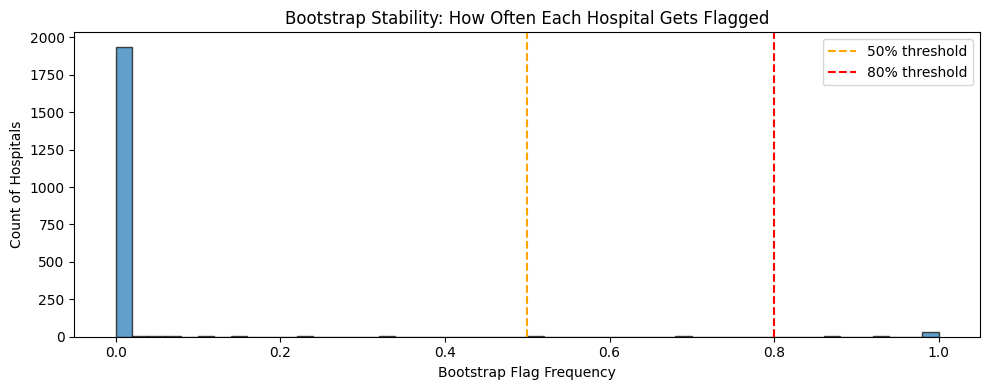

In [10]:
n_boot = 200
n_hospitals = X_pooled.shape[0]
flag_counts = np.zeros(n_hospitals, dtype=int)

rng = np.random.default_rng(42)
for b in range(n_boot):
    idx = rng.choice(n_hospitals, size=n_hospitals, replace=True)
    X_boot = X_pooled[idx]
    iso_boot = IsolationForest(contamination="auto", n_estimators=300, random_state=b)
    iso_boot.fit(X_boot)
    scores_boot = iso_boot.decision_function(X_pooled)  # score ALL hospitals
    thresh_boot = np.percentile(scores_boot, 2.5)
    flag_counts += (scores_boot < thresh_boot).astype(int)

df_pooled["bootstrap_flag_pct"] = flag_counts / n_boot

stable_80 = (df_pooled.loc[df_pooled["anomaly_flag"], "bootstrap_flag_pct"] >= 0.80).mean()
stable_50 = (df_pooled.loc[df_pooled["anomaly_flag"], "bootstrap_flag_pct"] >= 0.50).mean()

print(f"Bootstrap Stability ({n_boot} iterations)")
print("=" * 50)
print(f"  Flagged hospitals in >=80% of bootstraps: {stable_80:.1%}")
print(f"  Flagged hospitals in >=50% of bootstraps: {stable_50:.1%}")
print(f"  Mean bootstrap flag rate for flagged hospitals: {df_pooled.loc[df_pooled['anomaly_flag'], 'bootstrap_flag_pct'].mean():.3f}")
print(f"  Mean bootstrap flag rate for non-flagged: {df_pooled.loc[~df_pooled['anomaly_flag'], 'bootstrap_flag_pct'].mean():.3f}")

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(df_pooled["bootstrap_flag_pct"], bins=50, edgecolor="black", alpha=0.7)
ax.axvline(0.5, color="orange", linestyle="--", label="50% threshold")
ax.axvline(0.8, color="red", linestyle="--", label="80% threshold")
ax.set_xlabel("Bootstrap Flag Frequency")
ax.set_ylabel("Count of Hospitals")
ax.set_title("Bootstrap Stability: How Often Each Hospital Gets Flagged")
ax.legend()
plt.tight_layout()
plt.show()

In [11]:
explainer = shap.TreeExplainer(iso_model)
shap_values_raw = explainer.shap_values(X_pooled)

if isinstance(shap_values_raw, list):
    shap_values = np.array(shap_values_raw[0], dtype=float)
else:
    shap_values = np.array(shap_values_raw, dtype=float)

if shap_values.ndim == 1:
    shap_values = shap_values.reshape(1, -1)

assert shap_values.ndim == 2, f"Expected 2D shap_values, got shape {shap_values.shape}"
assert shap_values.shape == X_pooled.shape, f"Shape mismatch: shap {shap_values.shape} vs X {X_pooled.shape}"

print(f"SHAP values shape: {shap_values.shape}")

SHAP values shape: (2016, 9)


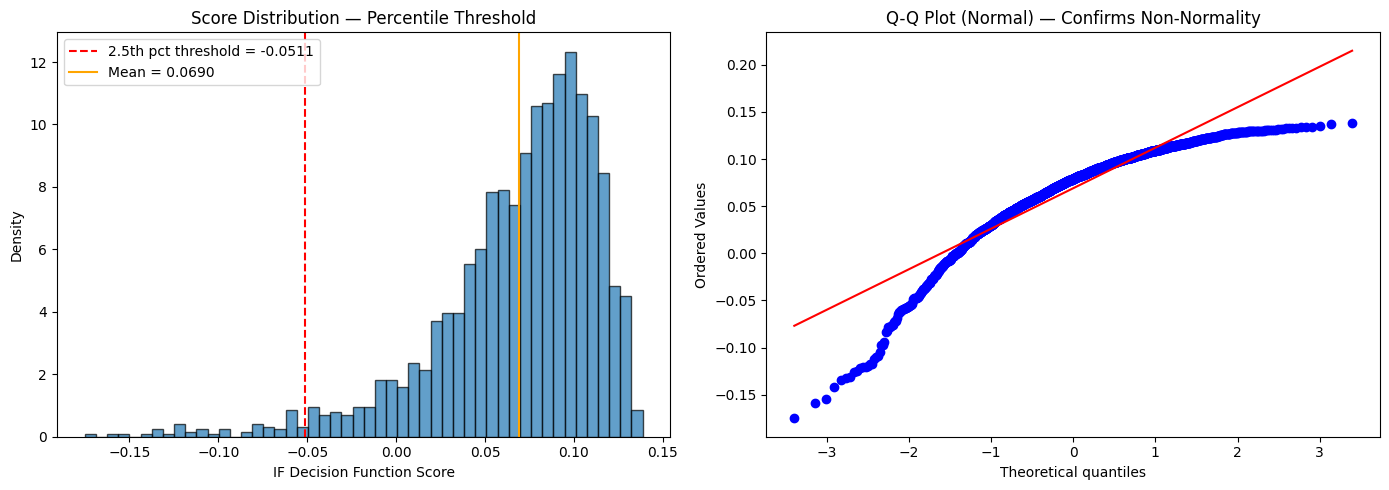

Skewness: -1.517 | Excess Kurtosis: 3.279
Using 2.5th percentile threshold: -0.0511
Flagged 51 hospitals (distribution-agnostic, no normality assumption)


In [12]:
from scipy import stats

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(scores, bins=50, edgecolor='black', alpha=0.7, density=True)
axes[0].axvline(threshold, color='red', linestyle='--', label=f'2.5th pct threshold = {threshold:.4f}')
axes[0].axvline(scores.mean(), color='orange', linestyle='-', label=f'Mean = {scores.mean():.4f}')
axes[0].set_xlabel('IF Decision Function Score')
axes[0].set_ylabel('Density')
axes[0].set_title('Score Distribution — Percentile Threshold')
axes[0].legend()

stats.probplot(scores, dist='norm', plot=axes[1])
axes[1].set_title('Q-Q Plot (Normal) — Confirms Non-Normality')

plt.tight_layout()
plt.show()

skewness = stats.skew(scores)
kurtosis_val = stats.kurtosis(scores)
print(f"Skewness: {skewness:.3f} | Excess Kurtosis: {kurtosis_val:.3f}")
print(f"Using 2.5th percentile threshold: {threshold:.4f}")
print(f"Flagged {flagged_total} hospitals (distribution-agnostic, no normality assumption)")

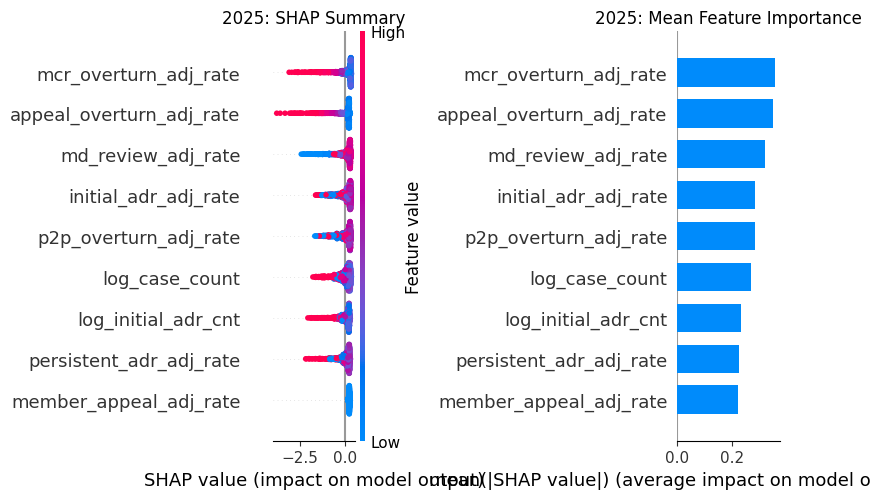

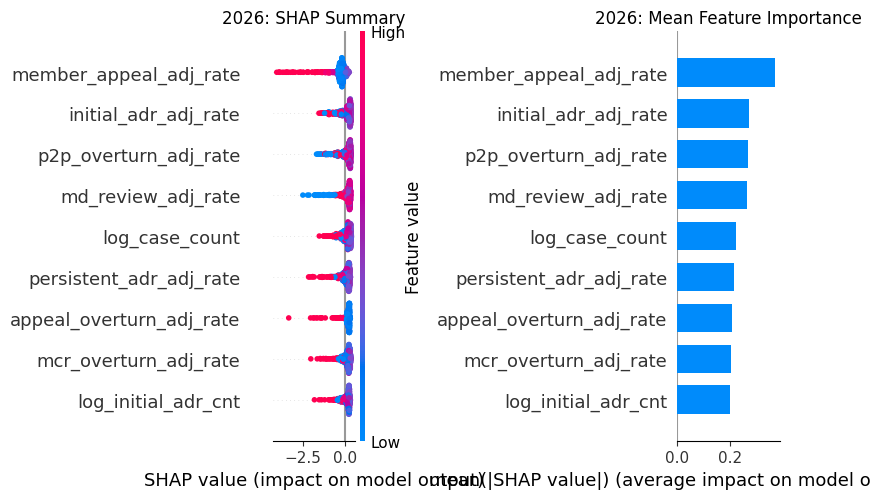

In [13]:
for yr in ["2025", "2026"]:
    mask = (df_pooled["year"] == yr).values
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    plt.sca(axes[0])
    shap.summary_plot(shap_values[mask], X_pooled[mask], feature_names=iso_kpi, show=False)
    axes[0].set_title(f"{yr}: SHAP Summary")

    plt.sca(axes[1])
    shap.summary_plot(shap_values[mask], X_pooled[mask], feature_names=iso_kpi, plot_type="bar", show=False)
    axes[1].set_title(f"{yr}: Mean Feature Importance")

    plt.tight_layout()
    plt.show()

In [14]:
flagged_mask = df_pooled["anomaly_flag"].values
flagged_pos = np.where(flagged_mask)[0]

shap_flagged = pd.DataFrame(
    shap_values[flagged_pos, :],
    columns=iso_kpi,
    index=range(len(flagged_pos))
)
shap_flagged["hospital_group"] = df_pooled.iloc[flagged_pos]["hospital_group"].values
shap_flagged["fin_market"] = df_pooled.iloc[flagged_pos]["fin_market"].values
shap_flagged["year"] = df_pooled.iloc[flagged_pos]["year"].values
shap_flagged["anomaly_rank"] = df_pooled.iloc[flagged_pos]["anomaly_rank"].values
shap_flagged["bootstrap_flag_pct"] = df_pooled.iloc[flagged_pos]["bootstrap_flag_pct"].values

shap_flagged["_driver_col"] = shap_flagged[iso_kpi].idxmin(axis=1)
shap_flagged["shap_driver_value"] = shap_flagged[iso_kpi].min(axis=1)

driver_actual = []
for i, col in enumerate(shap_flagged["_driver_col"]):
    driver_actual.append(df_pooled.iloc[flagged_pos[i]][col])
shap_flagged["driver_actual_value"] = driver_actual

feature_medians = df_pooled[iso_kpi].median()
shap_flagged["driver_direction"] = [
    "high" if v > feature_medians[c] else "low"
    for v, c in zip(shap_flagged["driver_actual_value"], shap_flagged["_driver_col"])
]
shap_flagged["shap_driver"] = shap_flagged["_driver_col"] + " (" + shap_flagged["driver_direction"] + ")"
shap_flagged.drop(columns="_driver_col", inplace=True)

print(f"Flagged: {len(shap_flagged)} hospital-years")
shap_flagged[["hospital_group", "fin_market", "year", "anomaly_rank", "bootstrap_flag_pct", "shap_driver", "shap_driver_value", "driver_actual_value"]].sort_values("anomaly_rank")

Flagged: 51 hospital-years


,hospital_group,fin_market,year,anomaly_rank,bootstrap_flag_pct,shap_driver,shap_driver_value,driver_actual_value
44,ADVOCATE HEALTH & HOSPITALS IL,IL,2026,1,1.000,md_review_adj_rate (low),-1.774836,0.019332
13,OKLAHOMA SPINE HOSPITAL,OK,2025,2,1.000,appeal_overturn_adj_rate (high),-3.094955,0.189598
36,Atrium Health System,NC,2026,3,1.000,member_appeal_adj_rate (high),-3.371083,0.670268
42,NORTH CAROLINA BAPTIST HOSPITAL SYSTEM,NC,2026,4,1.000,member_appeal_adj_rate (high),-3.522504,0.669120
9,Ascension MI,MI,2025,5,1.000,md_review_adj_rate (low),-1.672479,0.118846
3,MAYO CLINIC,MN,2025,6,1.000,md_review_adj_rate (low),-2.040109,0.059928
49,WESTCHESTER GENERAL HOSPITAL,FL,2026,7,1.000,persistent_adr_adj_rate (high),-1.937758,0.501609
5,ADVOCATE HEALTH & HOSPITALS IL,IL,2025,8,1.000,md_review_adj_rate (low),-1.979190,0.023522
23,SURGICAL CARE AFFILIATES,IL,2025,9,1.000,md_review_adj_rate (low),-2.086895,0.029940
26,Stanford Health Hospital,CA-N,2025,10,1.000,appeal_overturn_adj_rate (high),-2.774682,0.073012



OKLAHOMA SPINE HOSPITAL | Rank #2 (2025) | Bootstrap: 100%


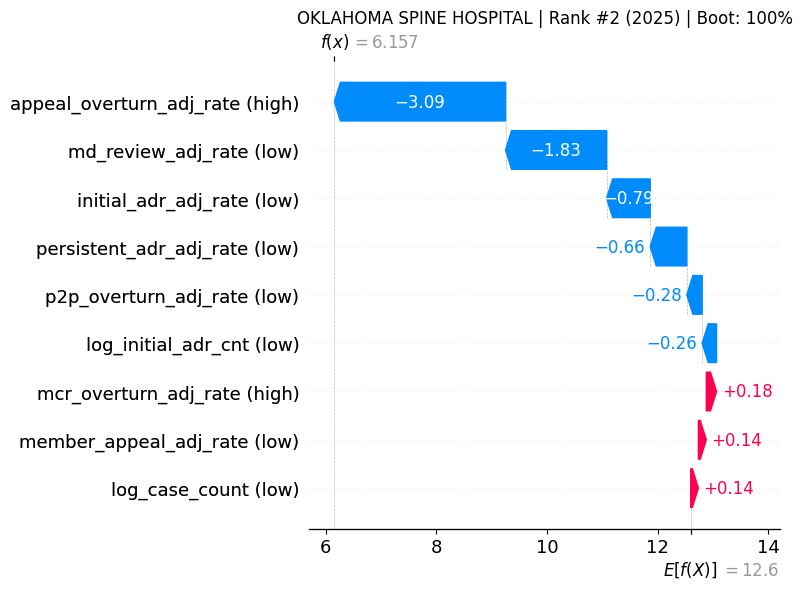


Ascension MI | Rank #5 (2025) | Bootstrap: 100%


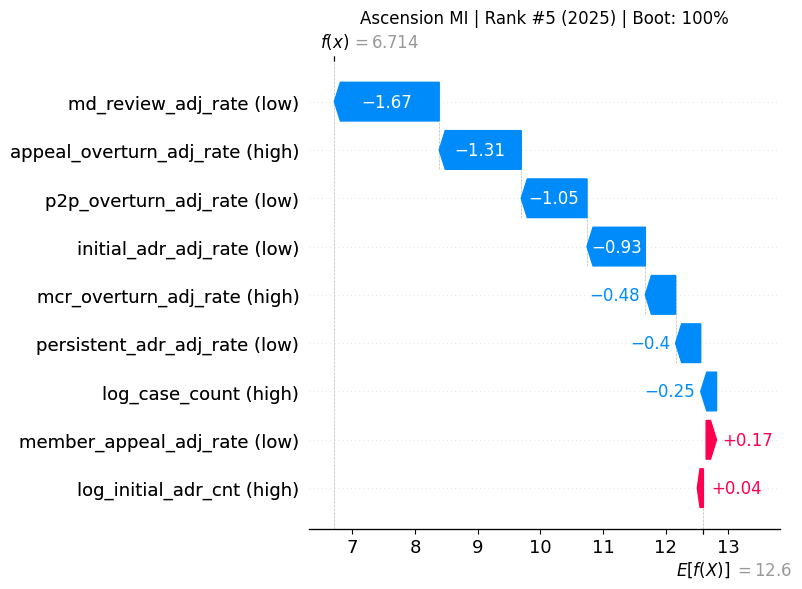


MAYO CLINIC | Rank #6 (2025) | Bootstrap: 100%


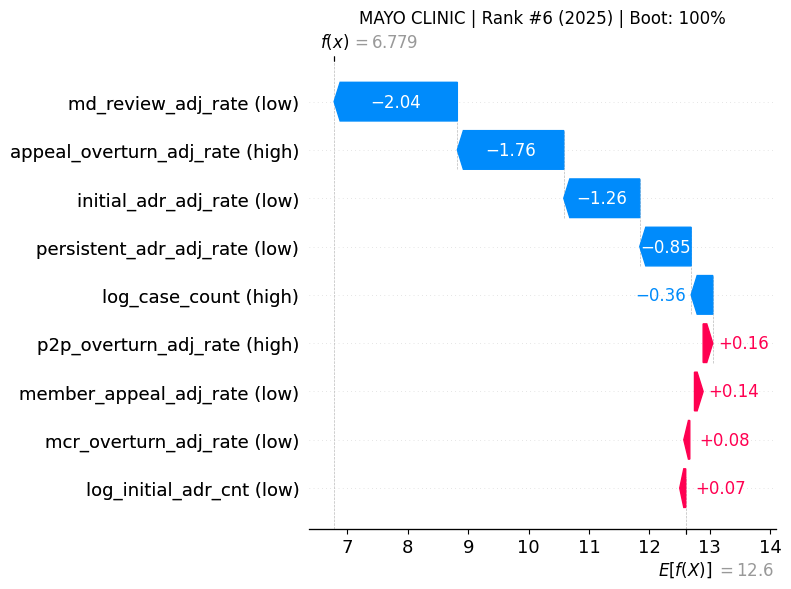


ADVOCATE HEALTH & HOSPITALS IL | Rank #8 (2025) | Bootstrap: 100%


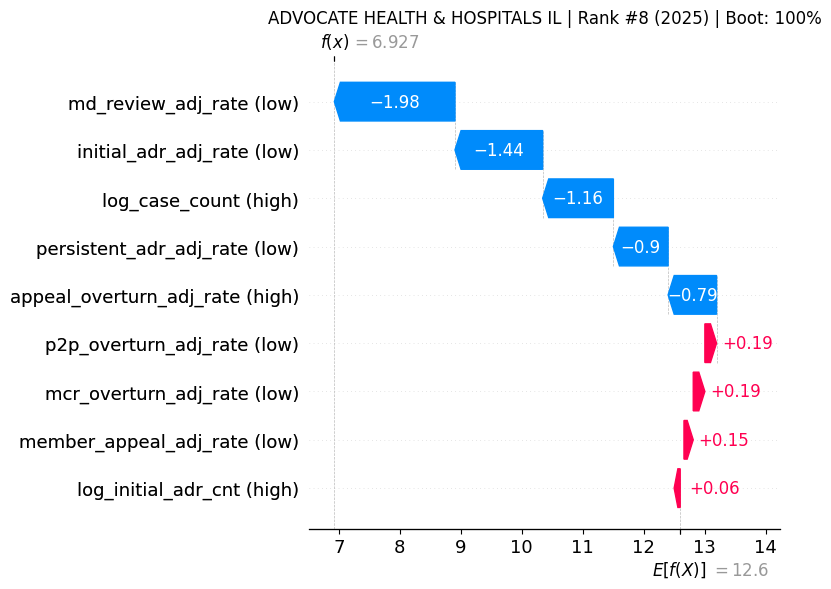


SURGICAL CARE AFFILIATES | Rank #9 (2025) | Bootstrap: 100%


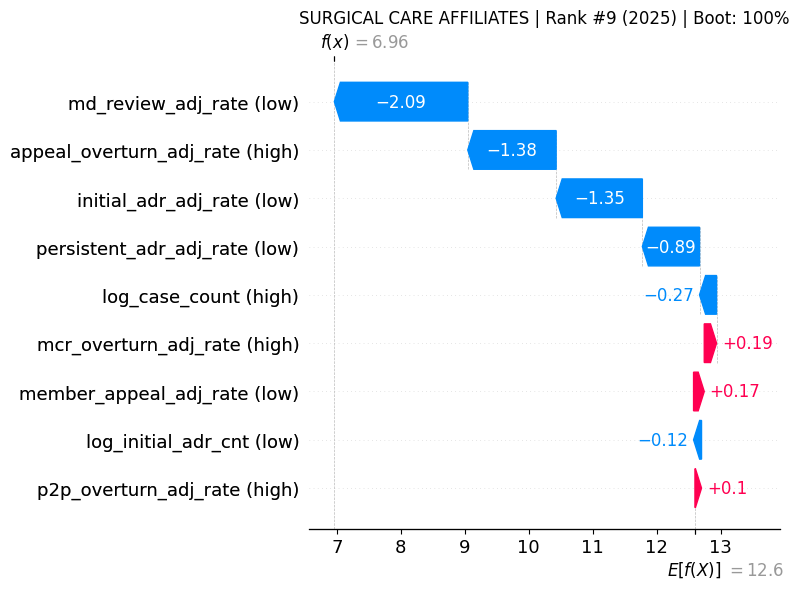


ADVOCATE HEALTH & HOSPITALS IL | Rank #1 (2026) | Bootstrap: 100%


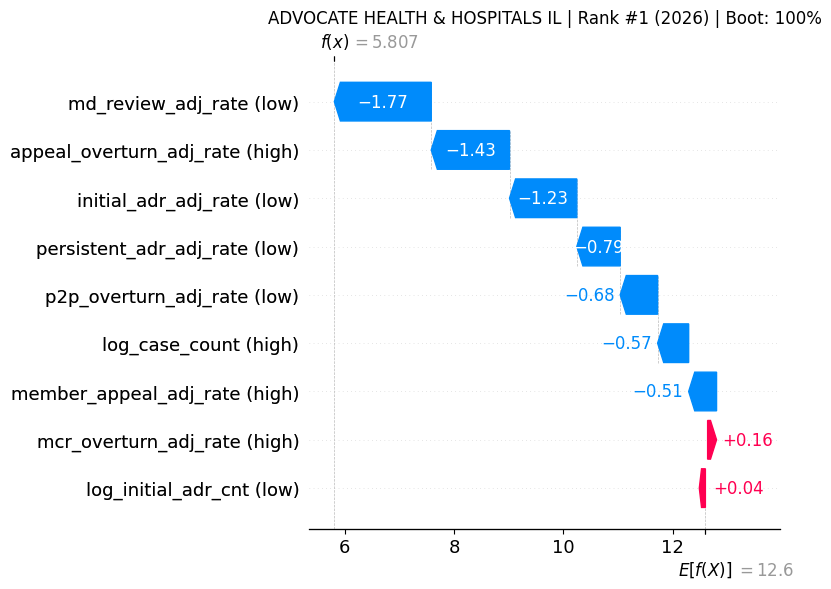


Atrium Health System | Rank #3 (2026) | Bootstrap: 100%


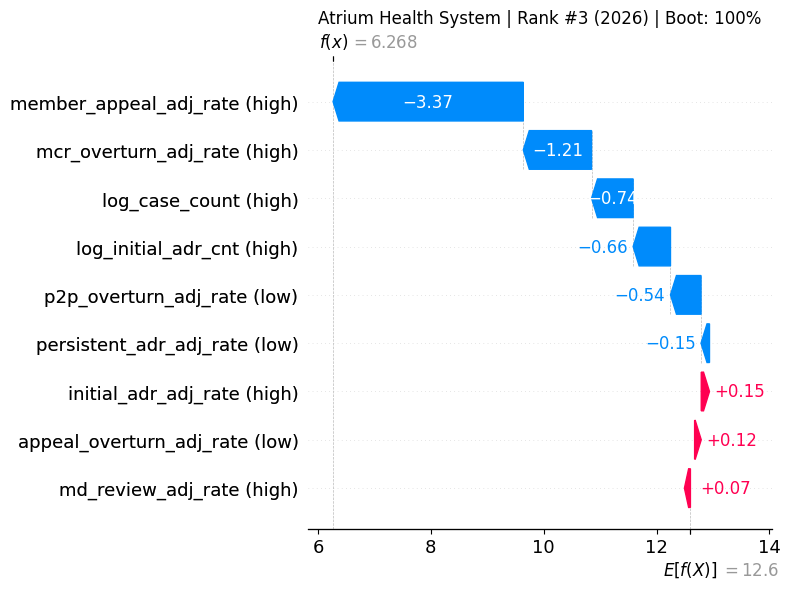


NORTH CAROLINA BAPTIST HOSPITAL SYSTEM | Rank #4 (2026) | Bootstrap: 100%


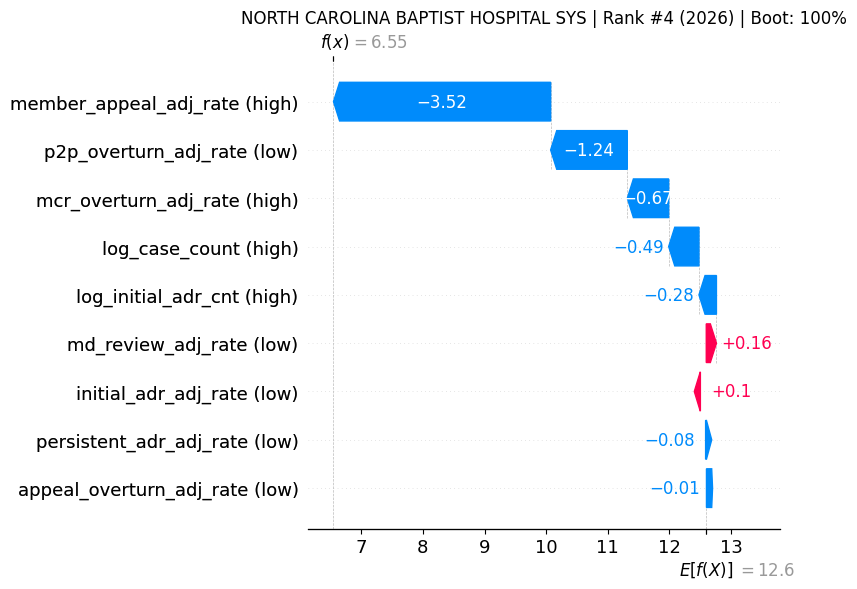


WESTCHESTER GENERAL HOSPITAL | Rank #7 (2026) | Bootstrap: 100%


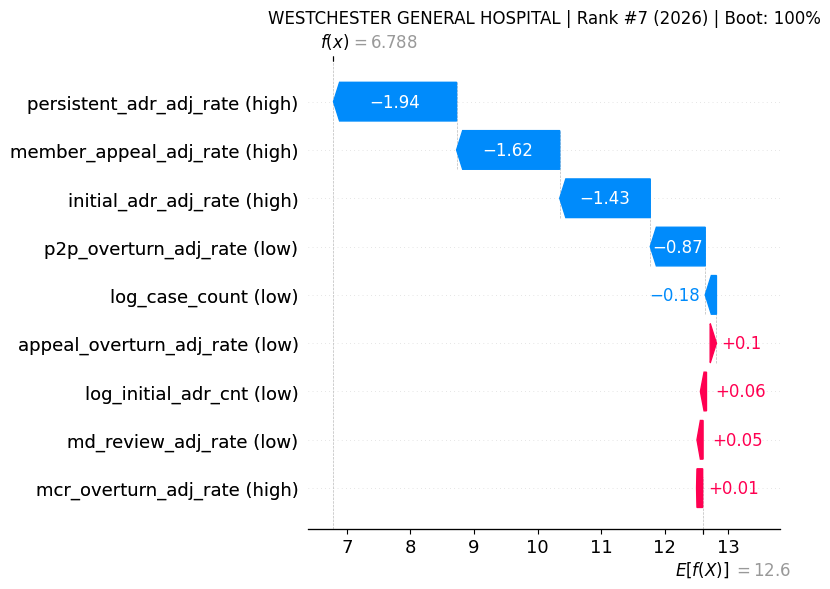


HUGH CHATHAM MEMORIAL HOSPITAL | Rank #11 (2026) | Bootstrap: 100%


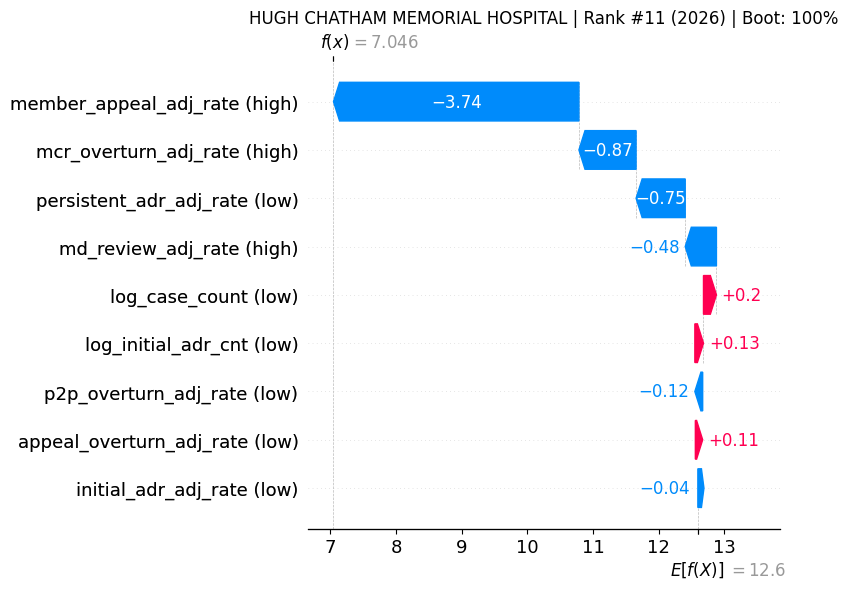

In [15]:
base_val = float(explainer.expected_value) if np.ndim(explainer.expected_value) == 0 else float(explainer.expected_value[0])
feature_medians = df_pooled[iso_kpi].median()

for yr in ["2025", "2026"]:
    yr_mask = (df_pooled["year"] == yr).values
    flag_mask = df_pooled["anomaly_flag"].values
    name_mask = df_pooled["hospital_group"].notna().values
    combined = yr_mask & flag_mask & name_mask

    candidates = df_pooled.iloc[np.where(combined)[0]].copy()
    candidates["_pos"] = np.where(combined)[0]
    top5 = candidates.nsmallest(5, "anomaly_rank")

    for _, row in top5.iterrows():
        pos = int(row["_pos"])
        hospital_name = row["hospital_group"]
        rank = int(row["anomaly_rank"])
        boot_pct = row["bootstrap_flag_pct"]

        feat_labels = [
            f"{col} ({'high' if df_pooled.iloc[pos][col] > feature_medians[col] else 'low'})"
            for col in iso_kpi
        ]

        print(f"\n{'=' * 60}")
        print(f"{hospital_name} | Rank #{rank} ({yr}) | Bootstrap: {boot_pct:.0%}")
        print(f"{'=' * 60}")

        explanation = shap.Explanation(
            values=shap_values[pos],
            base_values=base_val,
            feature_names=feat_labels
        )
        shap.waterfall_plot(explanation, show=False)
        plt.title(f"{hospital_name[:35]} | Rank #{rank} ({yr}) | Boot: {boot_pct:.0%}")
        plt.tight_layout()
        plt.show()

In [16]:
member_appeal_idx = iso_kpi.index("member_appeal_adj_rate")
mask_2025 = (df_pooled["year"] == "2025").values
mask_2026 = (df_pooled["year"] == "2026").values

shap_ma_2025 = shap_values[mask_2025, member_appeal_idx]
shap_ma_2026 = shap_values[mask_2026, member_appeal_idx]

print("=" * 60)
print("member_appeal_adj_rate SHAP — 2025 (imputed constant)")
print("=" * 60)
print(f"  Mean:   {shap_ma_2025.mean():.6f}")
print(f"  Std:    {shap_ma_2025.std():.6f}")
print(f"  |Max|:  {np.abs(shap_ma_2025).max():.6f}")
print()
print("=" * 60)
print("member_appeal_adj_rate SHAP — 2026 (actual variation)")
print("=" * 60)
print(f"  Mean:   {shap_ma_2026.mean():.6f}")
print(f"  Std:    {shap_ma_2026.std():.6f}")
print(f"  |Max|:  {np.abs(shap_ma_2026).max():.6f}")
print()

max_abs_2025 = np.abs(shap_ma_2025).max()
overall_shap_scale = np.abs(shap_values).mean()
ratio = max_abs_2025 / overall_shap_scale if overall_shap_scale > 0 else 0

print("=" * 60)
print("VERDICT")
print("=" * 60)
print(f"  Max |SHAP| for 2025 member_appeal: {max_abs_2025:.6f}")
print(f"  Overall mean |SHAP|: {overall_shap_scale:.6f}")
print(f"  Ratio: {ratio:.4f}")
if ratio < 0.05:
    print("  PASS — member_appeal contribution is negligible for 2025 rows")
else:
    print("  WARN — member_appeal SHAP is NOT negligible for 2025 rows")

member_appeal_adj_rate SHAP — 2025 (imputed constant)
  Mean:   0.223976
  Std:    0.017359
  |Max|:  0.266224

member_appeal_adj_rate SHAP — 2026 (actual variation)
  Mean:   -0.352096
  Std:    0.582226
  |Max|:  4.066067

VERDICT
  Max |SHAP| for 2025 member_appeal: 0.266224
  Overall mean |SHAP|: 0.269606
  Ratio: 0.9875
  WARN — member_appeal SHAP is NOT negligible for 2025 rows


In [17]:
adj_rate_cols = [
    "initial_adr_adj_rate", "persistent_adr_adj_rate", "p2p_overturn_adj_rate",
    "appeal_overturn_adj_rate", "mcr_overturn_adj_rate", "md_review_adj_rate",
    "member_appeal_adj_rate"
]
all_rate_cols = [
    "initial_adr_rate", "persistent_adr_rate", "p2p_overturn_rate",
    "appeal_overturn_rate", "mcr_overturn_rate", "md_review_rate",
]
adj_to_raw = dict(zip(adj_rate_cols[:6], all_rate_cols))
adj_medians = df_pooled[iso_kpi].median()
raw_med_case = df_pooled["case_count"].median()
raw_med_adr = df_pooled["initial_adr_cnt"].median()

driver_col_raw = shap_flagged["shap_driver"].str.replace(r" \((high|low)\)$", "", regex=True)

def _resolve_driver_metrics(row):
    drv = row["driver"]
    if not drv:
        return pd.Series([np.nan, np.nan, np.nan, np.nan],
                         index=["driver_value", "driver_adj_median", "driver_raw_median", "driver_dev_pct"])
    if drv == "log_case_count":
        val = row["case_count"]
        return pd.Series([val, raw_med_case, raw_med_case, (val - raw_med_case) / raw_med_case],
                         index=["driver_value", "driver_adj_median", "driver_raw_median", "driver_dev_pct"])
    if drv == "log_initial_adr_cnt":
        val = row["initial_adr_cnt"]
        return pd.Series([val, raw_med_adr, raw_med_adr, (val - raw_med_adr) / raw_med_adr],
                         index=["driver_value", "driver_adj_median", "driver_raw_median", "driver_dev_pct"])
    val = row[drv] if drv in row.index else np.nan
    med = adj_medians.get(drv, np.nan)
    raw_col = adj_to_raw.get(drv)
    raw_med = df_pooled[raw_col].median() if (raw_col and raw_col in df_pooled.columns) else np.nan
    dev_pct = (val - med) / med if (med and med != 0) else np.nan
    return pd.Series([val, med, raw_med, dev_pct],
                     index=["driver_value", "driver_adj_median", "driver_raw_median", "driver_dev_pct"])

output_cols = [
    "hospital_group", "fin_market", "year", "case_count", "initial_adr_cnt",
    "anomaly_score", "anomaly_rank", "percentile_rank", "anomaly_flag", "bootstrap_flag_pct",
] + adj_rate_cols + all_rate_cols

df_output = df_pooled[output_cols].copy()
df_output["shap_driver"] = np.nan
df_output["shap_driver_value"] = np.nan
df_output["driver_direction"] = np.nan

for idx in shap_flagged.index:
    pos = flagged_pos[idx]
    df_output.iloc[pos, df_output.columns.get_loc("shap_driver")] = shap_flagged.loc[idx, "shap_driver"]
    df_output.iloc[pos, df_output.columns.get_loc("shap_driver_value")] = shap_flagged.loc[idx, "shap_driver_value"]
    df_output.iloc[pos, df_output.columns.get_loc("driver_direction")] = shap_flagged.loc[idx, "driver_direction"]

df_output = df_output.sort_values("anomaly_rank").reset_index(drop=True)
print(f"Output: {df_output.shape}")
print(f"  Flagged: {df_output['anomaly_flag'].sum()}")
print(f"  Stable (boot >=80%): {(df_output.loc[df_output['anomaly_flag'], 'bootstrap_flag_pct'] >= 0.80).sum()}")
df_output.head(10)

Output: (2016, 26)
  Flagged: 51
  Stable (boot >=80%): 39


C:\Users\knguy139\AppData\Local\Temp\ipykernel_24660\1825253812.py:50: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'appeal_overturn_adj_rate (high)' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_output.iloc[pos, df_output.columns.get_loc("shap_driver")] = shap_flagged.loc[idx, "shap_driver"]
C:\Users\knguy139\AppData\Local\Temp\ipykernel_24660\1825253812.py:52: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'high' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_output.iloc[pos, df_output.columns.get_loc("driver_direction")] = shap_flagged.loc[idx, "driver_direction"]


,hospital_group,fin_market,year,case_count,initial_adr_cnt,anomaly_score,anomaly_rank,percentile_rank,anomaly_flag,bootstrap_flag_pct,...,member_appeal_adj_rate,initial_adr_rate,persistent_adr_rate,p2p_overturn_rate,appeal_overturn_rate,mcr_overturn_rate,md_review_rate,shap_driver,shap_driver_value,driver_direction
0,ADVOCATE HEALTH & HOSPITALS IL,IL,2026,2555,29,-0.175108,1,0.0005,True,1.0,...,0.064629,0.011350,0.008611,0.000000,0.068966,0.034483,0.017221,md_review_adj_rate (low),-1.774836,low
1,OKLAHOMA SPINE HOSPITAL,OK,2025,138,10,-0.159315,2,0.0010,True,1.0,...,0.033556,0.072464,0.014493,0.000000,0.600000,0.000000,0.057971,appeal_overturn_adj_rate (high),-3.094955,high
2,Atrium Health System,NC,2026,4647,1506,-0.154381,3,0.0015,True,1.0,...,0.670268,0.324080,0.081773,0.109562,0.001992,0.072377,0.780504,member_appeal_adj_rate (high),-3.371083,high
3,NORTH CAROLINA BAPTIST HOSPITAL SYSTEM,NC,2026,2765,718,-0.142021,4,0.0020,True,1.0,...,0.669120,0.259675,0.091501,0.009749,0.000000,0.055710,0.713562,member_appeal_adj_rate (high),-3.522504,high
4,Ascension MI,MI,2025,1330,93,-0.134919,5,0.0025,True,1.0,...,0.033556,0.069925,0.048872,0.000000,0.043011,0.064516,0.115789,md_review_adj_rate (low),-1.672479,low
5,MAYO CLINIC,MN,2025,1695,57,-0.132112,6,0.0030,True,1.0,...,0.033556,0.033628,0.012979,0.403509,0.052632,0.000000,0.057227,md_review_adj_rate (low),-2.040109,low
6,WESTCHESTER GENERAL HOSPITAL,FL,2026,42,36,-0.131747,7,0.0035,True,1.0,...,0.153217,0.857143,0.738095,0.000000,0.000000,0.055556,0.642857,persistent_adr_adj_rate (high),-1.937758,high
7,ADVOCATE HEALTH & HOSPITALS IL,IL,2025,7393,78,-0.125853,8,0.0040,True,1.0,...,0.033556,0.010551,0.005681,0.346154,0.025641,0.012821,0.022859,md_review_adj_rate (low),-1.979190,low
8,SURGICAL CARE AFFILIATES,IL,2025,1030,12,-0.124448,9,0.0045,True,1.0,...,0.033556,0.011650,0.004854,0.500000,0.083333,0.000000,0.025243,md_review_adj_rate (low),-2.086895,low
9,Stanford Health Hospital,CA-N,2025,753,62,-0.121596,10,0.0050,True,1.0,...,0.033556,0.082337,0.033201,0.435484,0.096774,0.048387,0.175299,appeal_overturn_adj_rate (high),-2.774682,high


In [18]:
# # =============================================================================
# # WRITE TO SNOWFLAKE
# # =============================================================================
# from sqlalchemy import create_engine
# from snowflake.sqlalchemy import URL

# engine_write = create_engine(URL(
#     account       = "UHG-UHGDWAAS",
#     user          = "KHANG.NGUYEN@UHC.COM",
#     authenticator = "externalbrowser",
#     role          = "AZU_SDRP_VING_PRD_DEVELOPER_ROLE",
#     warehouse     = "VING_PRD_MNR_HCE_DATAINFRA_WH",
#     database      = "VING_PRD_TREND_DB",
#     schema        = "TMP_1M"
# ))

# df_write = df_output.copy()
# df_write.columns = [c.upper() for c in df_write.columns]

# df_write.to_sql(
#     "kn_loc_if_outlier_hospitals_mnr_2025_2026",
#     engine_write,
#     schema = "TMP_1M",
#     if_exists = "replace",
#     index = False
# )

# engine_write.dispose()

# print(f"Wrote {len(df_write)} rows to TMP_1M.KN_LOC_IF_OUTLIER_HOSPITALS_MNR_2025_2026")
# print(f"  2025: {(df_write['YEAR'] == '2025').sum()} rows")
# print(f"  2026: {(df_write['YEAR'] == '2026').sum()} rows")